# 🚍 GTFS Data Analysis - Transport Network

This notebook teaches you how to work with GTFS (General Transit Feed Specification) data.

The data come from: https://app.mecatran.com/utw/ws/gtfsfeed/static/lio?apiKey=2b160d626f783808095373766f18714901325e45&type=gtfs_lio

You can download it an place it under /data

## What is GTFS?
GTFS is a standard format for public transit schedules and associated geographic information. It consists of text files that contain information about:
- **stops.txt**: Transit stops (stations)
- **routes.txt**: Transit routes
- **trips.txt**: Trips for each route
- **stop_times.txt**: Times for each trip
- **calendar.txt**: Service days
- **shapes.txt**: Geographic paths of routes

In [2]:
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import folium
from shapely.geometry import Point, LineString

DATA_DIR = "data"

## Loading GTFS Data

GTFS data is just CSV files! We can load them with pandas.

In [3]:
stops = pd.read_csv(f"{DATA_DIR}/stops.txt")
routes = pd.read_csv(f"{DATA_DIR}/routes.txt")
trips = pd.read_csv(f"{DATA_DIR}/trips.txt")
stop_times = pd.read_csv(f"{DATA_DIR}/stop_times.txt")
calendar = pd.read_csv(f"{DATA_DIR}/calendar.txt")
shapes = pd.read_csv(f"{DATA_DIR}/shapes.txt")
print("✅ All GTFS files loaded!")
print(f"Stops: {len(stops)} rows")
print(f"Routes: {len(routes)} rows")
print(f"Trips: {len(trips)} rows")
print(f"Stop Times: {len(stop_times)} rows")

/tmp/ipykernel_44861/3016004192.py:4: DtypeWarning: Columns (0: stop_id) have mixed types. Specify dtype option on import or set low_memory=False.
  stop_times = pd.read_csv(f"{DATA_DIR}/stop_times.txt")


✅ All GTFS files loaded!
Stops: 12226 rows
Routes: 316 rows
Trips: 7374 rows
Stop Times: 123965 rows


## 1. Visualizing Stations (Stops)

Each stop has latitude (`stop_lat`) and longitude (`stop_lon`) coordinates.

In [4]:
stops.head()

,stop_id,stop_code,stop_name,stop_desc,stop_lat,stop_lon,zone_id,stop_url,location_type,parent_station,wheelchair_boarding
0,1000107,NaN,ABEILHAN - AV. F. MISTRAL,NaN,43.450486,3.294006,NaN,NaN,1,NaN,0
1,1000109,NaN,ABEILHAN - AV. MOLIERE,NaN,43.455459,3.295699,NaN,NaN,1,NaN,0
2,65S15034,NaN,ADAST - Route des Vallées,NaN,42.974975,-0.078322,NaN,NaN,1,NaN,0
3,1000115,NaN,ADISSAN - CLAIRETTE,NaN,43.535255,3.427682,NaN,NaN,1,NaN,0
4,1003769,NaN,AGDE - BALDY,NaN,43.307618,3.502164,NaN,NaN,1,NaN,0


### Creating a GeoDataFrame from stops

In [5]:
# Create geometry from lat/lon
stops["geometry"] = stops.apply(
    lambda row: Point(row["stop_lon"], row["stop_lat"]), axis=1
)

# Create GeoDataFrame with WGS84 (EPSG:4326)
stops_gdf = gpd.GeoDataFrame(stops, geometry="geometry", crs="EPSG:4326")

stops_gdf.head()

,stop_id,stop_code,stop_name,stop_desc,stop_lat,stop_lon,zone_id,stop_url,location_type,parent_station,wheelchair_boarding,geometry
0,1000107,NaN,ABEILHAN - AV. F. MISTRAL,NaN,43.450486,3.294006,NaN,NaN,1,NaN,0,POINT (3.29401 43.45049)
1,1000109,NaN,ABEILHAN - AV. MOLIERE,NaN,43.455459,3.295699,NaN,NaN,1,NaN,0,POINT (3.2957 43.45546)
2,65S15034,NaN,ADAST - Route des Vallées,NaN,42.974975,-0.078322,NaN,NaN,1,NaN,0,POINT (-0.07832 42.97498)
3,1000115,NaN,ADISSAN - CLAIRETTE,NaN,43.535255,3.427682,NaN,NaN,1,NaN,0,POINT (3.42768 43.53526)
4,1003769,NaN,AGDE - BALDY,NaN,43.307618,3.502164,NaN,NaN,1,NaN,0,POINT (3.50216 43.30762)


### Simple matplotlib map of all stops

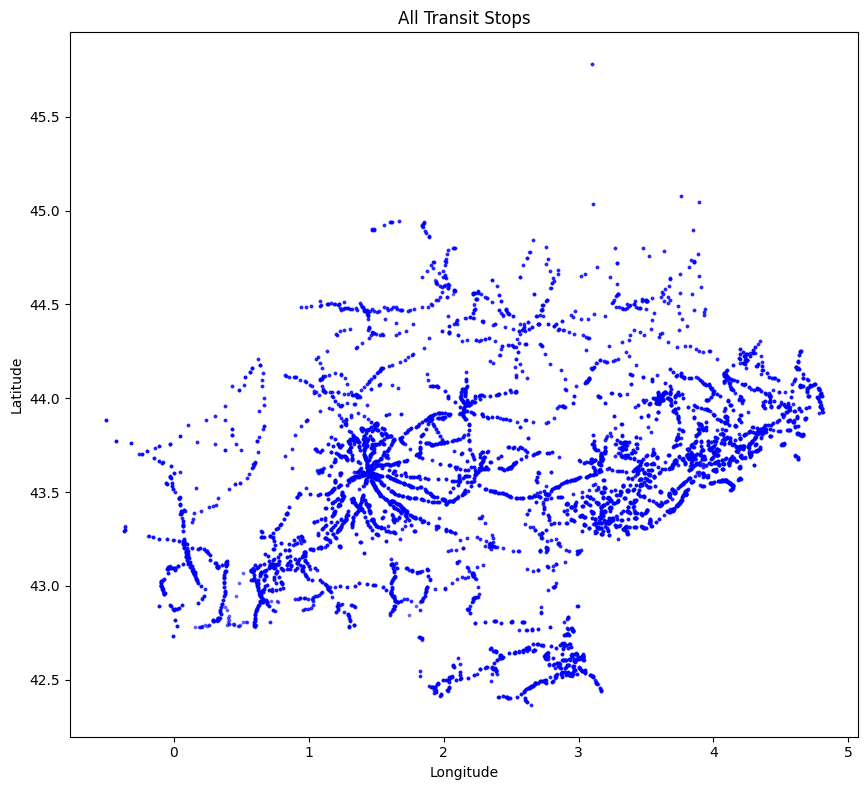

In [6]:
fig, ax = plt.subplots(figsize=(12, 8))
stops_gdf.plot(ax=ax, markersize=3, color="blue", alpha=0.5)
ax.set_title("All Transit Stops")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

### Interactive map with Folium

In [7]:
# Center map on the data
center_lat = stops_gdf["stop_lat"].mean()
center_lon = stops_gdf["stop_lon"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=9, tiles="cartodbpositron")

# Add first 100 stops (for performance)
for idx, row in stops_gdf.head(100).iterrows():
    folium.CircleMarker(
        location=[row["stop_lat"], row["stop_lon"]],
        radius=4,
        popup=row["stop_name"],
        color="blue",
        fill=True,
    ).add_to(m)

m

## 2. Visualizing Routes and Networks

Routes define the paths vehicles take. `route_type` indicates the type of transit:
- 0 = Tram
- 1 = Subway
- 2 = Rail
- 3 = Bus
- 4 = Ferry

In [8]:
routes.head()

,route_id,agency_id,route_short_name,route_long_name,route_type,route_url,route_color,route_text_color
0,101,130,101,CAMPESTRE ET LUC - LE VIGAN,3,NaN,74CFE2,000000
1,102,130,102,GANGES - SAINT-ROMAN DE CODIERES,3,NaN,F5AE81,000000
2,103,130,103,POMPIGNAN - SAINT-HIPPOLYTE DU FORT,3,NaN,718FAB,000000
3,104,130,104,LE VIGAN - ARPHY,3,NaN,246F25,FFFFFF
4,105,130,105,VISSEC - LE VIGAN,3,NaN,F072AB,000000


### Route types in this dataset

In [9]:
routes["route_type"].value_counts()

route_type
3    316
Name: count, dtype: int64

### Creating route geometries from shapes.txt

Shapes contain the GPS coordinates that define the path of each route.

In [10]:
shapes.head()

,shape_id,shape_pt_lat,shape_pt_lon,shape_pt_sequence,shape_dist_traveled
0,101A01,43.953011,3.420285,0,0.000000
1,101A01,43.953011,3.420300,1,1.183851
2,101A01,43.953232,3.420310,2,25.799685
3,101A01,43.953304,3.420299,3,33.906685
4,101A01,43.953381,3.420267,4,42.767288


Now let's create LineStrings for each shape.

In [11]:
# Create line geometries from shapes
def create_line(group):
    points = list(zip(group["shape_pt_lon"], group["shape_pt_lat"]))
    if len(points) > 1:
        return LineString(points)
    return None


shapes_grouped = shapes.groupby("shape_id").apply(create_line).reset_index()
shapes_grouped.columns = ["shape_id", "geometry"]
shapes_gdf = gpd.GeoDataFrame(shapes_grouped, geometry="geometry", crs="EPSG:4326")

print(f"Created {len(shapes_gdf)} route shapes")
shapes_gdf.head()

Created 2692 route shapes


,shape_id,geometry
0,101A01,"LINESTRING (3.42028 43.95301, 3.4203 43.95301,..."
1,101R01,"LINESTRING (3.6011 43.98875, 3.60108 43.98877,..."
2,102A01,"LINESTRING (3.77832 44.00272, 3.7783 44.00274,..."
3,102R01,"LINESTRING (3.7084 43.93547, 3.70842 43.93545,..."
4,103A01,"LINESTRING (3.85675 43.89342, 3.85674 43.89342..."


### Map routes with colors

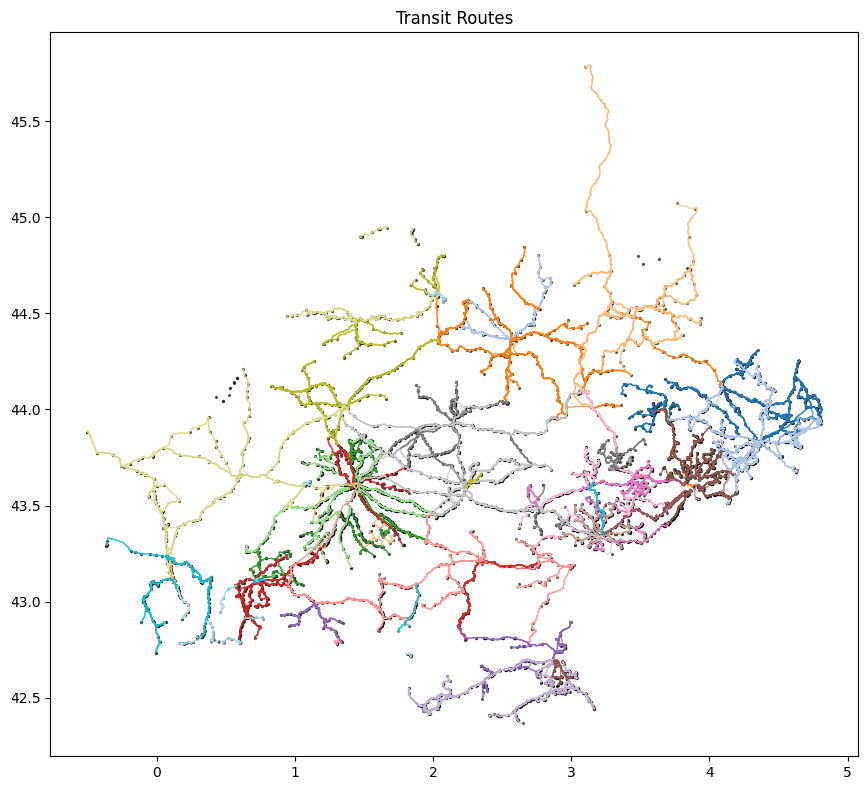

In [12]:
# Join shapes with routes via trips to get colors
trips_shapes = trips[["shape_id", "route_id"]].drop_duplicates()
routes_shapes = trips_shapes.merge(
    routes[["route_id", "route_short_name", "route_color"]], on="route_id"
)
shapes_with_routes = shapes_gdf.merge(
    routes_shapes[["shape_id", "route_short_name", "route_color"]], on="shape_id"
)

fig, ax = plt.subplots(figsize=(12, 8))
shapes_with_routes.plot(
    ax=ax, column="route_short_name", cmap="tab20", linewidth=1, alpha=0.7
)
stops_gdf.plot(ax=ax, markersize=2, color="black", alpha=0.3)
ax.set_title("Transit Routes")
plt.tight_layout()
plt.show()

## 3. Building a Transit Network Graph

We can use NetworkX to build a graph of connected stops.

In [ ]:
trip_id = trips.iloc[0]["trip_id"]  # or pick a specific one

path = (
    stop_times[stop_times["trip_id"] == trip_id]
    .sort_values("stop_sequence")["stop_id"]
    .tolist()
)

In [47]:
path

[3013518,
 3013114,
 3013168,
 3013170,
 3013222,
 3013157,
 3013414,
 3014070,
 3015230,
 3015232]

In [41]:
stops.loc[stops["stop_id"] == stop_id]

,stop_id,stop_code,stop_name,stop_desc,stop_lat,stop_lon,zone_id,stop_url,location_type,parent_station,wheelchair_boarding,geometry
5975,3013518,NaN,CAMPESTRE-ET-LUC - Village,arrêt commercial,43.95301,3.420285,NaN,NaN,0,30S13518,0,POINT (3.420285 43.95301)


In [31]:
stops

,stop_id,stop_code,stop_name,stop_desc,stop_lat,stop_lon,zone_id,stop_url,location_type,parent_station,wheelchair_boarding,geometry
0,1000107,NaN,ABEILHAN - AV. F. MISTRAL,NaN,43.450486,3.294006,NaN,NaN,1,NaN,0,POINT (3.294006 43.450486)
1,1000109,NaN,ABEILHAN - AV. MOLIERE,NaN,43.455459,3.295699,NaN,NaN,1,NaN,0,POINT (3.295699 43.455459)
2,65S15034,NaN,ADAST - Route des Vallées,NaN,42.974975,-0.078322,NaN,NaN,1,NaN,0,POINT (-0.078322 42.974975)
3,1000115,NaN,ADISSAN - CLAIRETTE,NaN,43.535255,3.427682,NaN,NaN,1,NaN,0,POINT (3.427682 43.535255)
4,1003769,NaN,AGDE - BALDY,NaN,43.307618,3.502164,NaN,NaN,1,NaN,0,POINT (3.502164 43.307618)
...,...,...,...,...,...,...,...,...,...,...,...,...
12221,3015221,NaN,VÉZÉNOBRES - L'Orée du Bois,arrêt commercial,44.042130,4.146270,NaN,NaN,0,30S15221,0,POINT (4.14627 44.04213)
12222,3015213,NaN,VÉZÉNOBRES - Sarrazin,arrêt commercial,44.050630,4.132590,NaN,NaN,0,30S15214,0,POINT (4.13259 44.05063)
12223,3015214,NaN,VÉZÉNOBRES - Sarrazin,arrêt commercial,44.050950,4.132440,NaN,NaN,0,30S15214,0,POINT (4.13244 44.05095)
12224,6600278,NaN,ÉGAT - Auto Ecole,arrêt commercial,42.499636,2.018780,NaN,NaN,0,66S03850,0,POINT (2.01878 42.499636)


In [46]:
stop_id = "3013518"
stops.loc[stops["stop_id"] == stop_id]

,stop_id,stop_code,stop_name,stop_desc,stop_lat,stop_lon,zone_id,stop_url,location_type,parent_station,wheelchair_boarding,geometry
5975,3013518,NaN,CAMPESTRE-ET-LUC - Village,arrêt commercial,43.95301,3.420285,NaN,NaN,0,30S13518,0,POINT (3.420285 43.95301)


In [49]:
path_coords = []

for stop_id in path:
    stop_id = str(stop_id)
    match = stops.loc[stops["stop_id"] == stop_id]

    if match.empty:
        print(f"⚠️ stop_id not found: {stop_id}")
        continue
    else:
        print("OK")

    stop_data = match.iloc[0]
    path_coords.append([stop_data["stop_lat"], stop_data["stop_lon"]])

OK
OK
OK
OK
OK
OK
OK
OK
OK
OK


In [50]:
# Build a graph where stops are nodes and edges exist if a trip connects them
G = nx.Graph()

# Add all stops as nodes
for idx, stop in stops.iterrows():
    G.add_node(
        stop["stop_id"],
        name=stop["stop_name"],
        lat=stop["stop_lat"],
        lon=stop["stop_lon"],
    )

# Sort stop_times by trip_id and sequence to find connections
stop_times_sorted = stop_times.sort_values(["trip_id", "stop_sequence"])

# Add edges between consecutive stops in each trip
for trip_id, group in stop_times_sorted.groupby("trip_id"):
    stops_list = group["stop_id"].tolist()
    for i in range(len(stops_list) - 1):
        if not G.has_edge(stops_list[i], stops_list[i + 1]):
            G.add_edge(stops_list[i], stops_list[i + 1])

print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

Graph created with 16646 nodes and 10186 edges


## 4. Finding Shortest Path Between Two Points

Now we can find the shortest path (fewest hops) between any two stops!

In [61]:
# Find a few sample stops for demonstration
sample_stops = stops_gdf.head(10)[["stop_id", "stop_name", "stop_lat", "stop_lon"]]
sample_stops

,stop_id,stop_name,stop_lat,stop_lon
0,1000107,ABEILHAN - AV. F. MISTRAL,43.450486,3.294006
1,1000109,ABEILHAN - AV. MOLIERE,43.455459,3.295699
2,65S15034,ADAST - Route des Vallées,42.974975,-0.078322
3,1000115,ADISSAN - CLAIRETTE,43.535255,3.427682
4,1003769,AGDE - BALDY,43.307618,3.502164
5,1000133,AGDE - COMMISSARIAT,43.311853,3.476029
6,1000159,AGDE - GARE SNCF,43.316897,3.465950
7,1004179,AGDE - J. Jaures,43.314917,3.469360
8,1000251,AGDE - LA TREILLE,43.310703,3.482026
9,1003825,AGDE - LES GARRIGUES,43.308995,3.489043


Let's find the shortest path between two real stops.

In [62]:
# Example: Find stops with "GARE" (train station) in the name
gare_stops = stops[stops["stop_name"].str.contains("GARE", case=False, na=False)]
print("Stops with 'GARE' in name:")
print(gare_stops[["stop_id", "stop_name"]].head(10))

Stops with 'GARE' in name:
       stop_id                                 stop_name
6      1000159                          AGDE - GARE SNCF
12    32S01581                          AGEN - Gare SNCF
28     1005139                 AIGUES-MORTES - GARE SNCF
29    30S13040                 AIGUES-MORTES - Gare SNCF
61   81S219504                         ALBI - Gare  SNCF
62    81S98504                      ALBI - Gare Routière
79    48S03258                        ALLENC - Gare Sncf
101   30S03230                      ALÈS - Gare Routière
102   30S13077                      ALÈS - Gare Routière
121   66S00989  AMÉLIE-LES-BAINS-PALALDA - Gare Routiere


In [63]:
# Pick two stops to find path between
stop1 = gare_stops.iloc[0]["stop_id"]
stop2 = gare_stops.iloc[1]["stop_id"]
name1 = gare_stops.iloc[0]["stop_name"]
name2 = gare_stops.iloc[1]["stop_name"]

print(f"Finding path from: {name1} ({stop1})")
print(f"To: {name2} ({stop2})")

# Find shortest path (by number of stops)
try:
    path = nx.shortest_path(G, stop1, stop2)
    print(f"\nPath found with {len(path)} stops:")

    # Get stop names for the path
    path_names = []
    for stop_id in path:
        stop_name = stops[stops["stop_id"] == stop_id]["stop_name"].values[0]
        path_names.append(stop_name)

    for i, (sid, sname) in enumerate(zip(path, path_names)):
        print(f"  {i + 1}. {sname} ({sid})")
except nx.NetworkXNoPath:
    print("No path found between these stops!")

Finding path from: AGDE - GARE SNCF (1000159)
To: AGEN - Gare SNCF (32S01581)
No path found between these stops!


### Visualize the path on a map

In [64]:
# Get coordinates for path stops
path_coords = []
for stop_id in path:
    stop_data = stops[stops["stop_id"] == stop_id].iloc[0]
    path_coords.append([stop_data["stop_lat"], stop_data["stop_lon"]])

IndexError: single positional indexer is out-of-bounds

In [65]:
# Create map
m = folium.Map(location=path_coords[len(path_coords) // 2], zoom_start=11)

# Add all stops in gray
for idx, row in stops_gdf.iterrows():
    folium.CircleMarker(
        location=[row["stop_lat"], row["stop_lon"]],
        radius=2,
        color="gray",
        fill=True,
        opacity=0.5,
    ).add_to(m)

# Add path stops in blue
for stop_id in path:
    stop_data = stops[stops["stop_id"] == stop_id].iloc[0]
    folium.CircleMarker(
        location=[stop_data["stop_lat"], stop_data["stop_lon"]],
        radius=8,
        color="blue",
        fill=True,
        popup=stop_data["stop_name"],
    ).add_to(m)

# Draw path line
folium.PolyLine(path_coords, color="red", weight=3).add_to(m)

m

IndexError: list index out of range

## 5. More Useful Operations

### Finding stops near a location

In [ ]:
from math import radians, sin, cos, sqrt, atan2


def haversine(lat1, lon1, lat2, lon2):
    """Calculate distance in km between two points"""
    R = 6371  # Earth's radius in km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))


# Example: Find stops near AGDE
target_lat, target_lon = 43.31, 3.48

stops["distance_km"] = stops.apply(
    lambda row: haversine(target_lat, target_lon, row["stop_lat"], row["stop_lon"]),
    axis=1,
)

nearby = stops.nsmallest(10, "distance_km")[["stop_id", "stop_name", "distance_km"]]
print(f"Stops near ({target_lat}, {target_lon}):")
nearby

Stops near (43.31, 3.48):


,stop_id,stop_name,distance_km
4670,1004802,AGDE - La Treille,0.180364
8,1000251,AGDE - LA TREILLE,0.181610
4669,1000252,AGDE - LA TREILLE,0.181610
4666,1004804,AGDE - Commissariat,0.381087
5,1000133,AGDE - COMMISSARIAT,0.381686
4665,1000134,AGDE - COMMISSARIAT,0.381686
9,1003825,AGDE - LES GARRIGUES,0.740172
4671,1003826,AGDE - LES GARRIGUES,0.740172
4672,1004800,AGDE - Les Garrigues,0.749465
4674,1004806,AGDE - Promenade,0.850527


### Finding all trips for a specific route

In [ ]:
# Pick a route and see its trips
sample_route = routes.iloc[0]
print(f"Route: {sample_route['route_short_name']} - {sample_route['route_long_name']}")

route_trips = trips[trips["route_id"] == sample_route["route_id"]]
print(f"Number of trips: {len(route_trips)}")
route_trips.head()

Route: 101 - CAMPESTRE ET LUC - LE VIGAN
Number of trips: 2


,route_id,service_id,trip_id,trip_headsign,trip_short_name,direction_id,block_id,shape_id,wheelchair_accessible,bikes_allowed
0,101,7e6273386a42064a2f0b,101|20575521:T1|9:00:00,Le Vigan - Cité Scolaire,101-A01-09:00,0,NaN,101A01,0,0
1,101,7e6273386a42064a2f0b,101|20575570:T1|12:00:00,Campestre-et-Luc - Village,101-R01-12:00,1,NaN,101R01,0,0


### Get all stops for a route (in order)

In [ ]:
first_trip = route_trips.iloc[0]["trip_id"]
trip_stops = (
    stop_times[stop_times["trip_id"] == first_trip]
    .merge(stops[["stop_id", "stop_name", "stop_lat", "stop_lon"]], on="stop_id")
    .sort_values("stop_sequence")
)

print(f"Stops for trip {first_trip}:")
trip_stops[["stop_sequence", "stop_name", "arrival_time", "departure_time"]]

Stops for trip 101|20575521:T1|9:00:00:


,stop_sequence,stop_name,arrival_time,departure_time


## Summary

You've learned:
1. ✅ Loading GTFS CSV files with pandas
2. ✅ Converting stops to GeoDataFrame and visualizing
3. ✅ Creating interactive maps with Folium
4. ✅ Visualizing route shapes
5. ✅ Building a NetworkX graph from transit data
6. ✅ Finding shortest paths between stops
7. ✅ Finding nearby stops
8. ✅ Getting route schedules and stops